In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.calibration import CalibratedClassifierCV

In [2]:
df = pd.read_csv("data/toxicology_dataset_strong_v5.csv")

In [3]:
df.head()

,fever,vomiting,diarrhea,anorexia,dehydration,sudden_onset,progressive_deterioration,feed_exposure,radiation_pattern,herd_cluster,...,cell_damage_score,gi_damage_score,multi_organ_damage,marrow_suppression,renal_injury_score,hepatic_injury_score,time_to_onset_hours,clinical_severity,forensic_suspicion_score,result
0,0,0,0,0,0,0,0,0,0,0,...,2,0,0,0,1,1,80,4,2,Normal
1,0,1,0,1,0,1,1,0,1,0,...,3,0,3,3,3,3,106,12,10,Polonium-like
2,0,0,0,0,0,1,0,0,0,0,...,0,0,1,2,0,0,56,3,2,Normal
3,1,0,0,1,0,0,1,0,1,0,...,2,1,3,2,2,3,106,10,8,Polonium-like
4,0,0,0,0,0,0,0,0,0,0,...,3,0,2,0,2,2,71,8,5,Normal


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   fever                      1100 non-null   int64 
 1   vomiting                   1100 non-null   int64 
 2   diarrhea                   1100 non-null   int64 
 3   anorexia                   1100 non-null   int64 
 4   dehydration                1100 non-null   int64 
 5   sudden_onset               1100 non-null   int64 
 6   progressive_deterioration  1100 non-null   int64 
 7   feed_exposure              1100 non-null   int64 
 8   radiation_pattern          1100 non-null   int64 
 9   herd_cluster               1100 non-null   int64 
 10  weakness_score             1100 non-null   int64 
 11  cell_damage_score          1100 non-null   int64 
 12  gi_damage_score            1100 non-null   int64 
 13  multi_organ_damage         1100 non-null   int64 
 14  marrow_s

In [5]:
df["result"].value_counts()

result
Normal           420
Ricin-like       260
Polonium-like    220
Borderline       200
Name: count, dtype: int64

In [6]:
df.groupby("result").mean(numeric_only=True).round(2)

,fever,vomiting,diarrhea,anorexia,dehydration,sudden_onset,progressive_deterioration,feed_exposure,radiation_pattern,herd_cluster,weakness_score,cell_damage_score,gi_damage_score,multi_organ_damage,marrow_suppression,renal_injury_score,hepatic_injury_score,time_to_onset_hours,clinical_severity,forensic_suspicion_score
result,,,,,,,,,,,,,,,,,,,,
Borderline,0.52,0.34,0.40,0.60,0.44,0.40,0.44,0.34,0.30,0.24,1.80,1.80,1.76,1.86,1.66,1.50,1.68,39.64,8.88,5.78
Normal,0.25,0.10,0.16,0.20,0.08,0.10,0.13,0.07,0.03,0.21,0.84,0.78,0.62,0.61,0.32,0.60,0.77,59.79,3.17,1.82
Polonium-like,0.46,0.29,0.18,0.81,0.30,0.15,0.82,0.10,0.79,0.16,2.33,2.49,1.46,2.82,2.60,2.69,2.46,93.35,11.69,8.04
Ricin-like,0.73,0.82,0.77,0.71,0.68,0.77,0.42,0.78,0.09,0.42,2.31,2.53,2.48,2.24,0.65,2.15,2.57,5.52,10.21,7.70


In [7]:
feature_columns = [
    "fever",
    "vomiting",
    "diarrhea",
    "anorexia",
    "dehydration",
    "sudden_onset",
    "progressive_deterioration",
    "feed_exposure",
    "radiation_pattern",
    "herd_cluster",
    "weakness_score",
    "cell_damage_score",
    "gi_damage_score",
    "multi_organ_damage",
    "marrow_suppression",
    "renal_injury_score",
    "hepatic_injury_score",
    "time_to_onset_hours"
]

target_column = "result"

X = df[feature_columns]
y = df[target_column]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (880, 18)
Test: (220, 18)


# Random Forest Model

In [10]:
base_model = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

In [11]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 8, 12, 16],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [13]:
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

In [14]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 8, 12, 16],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [15]:
best_rf = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}


In [16]:
train_pred = best_rf.predict(X_train)
test_pred = best_rf.predict(X_test)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print("=== Before Calibration ===")
print("Train Accuracy:", round(train_accuracy, 4))
print("Test Accuracy:", round(test_accuracy, 4))

=== Before Calibration ===
Train Accuracy: 0.9909
Test Accuracy: 0.9227


In [17]:
print(classification_report(y_test, test_pred))

               precision    recall  f1-score   support

   Borderline       0.83      0.75      0.79        40
       Normal       0.94      0.95      0.95        84
Polonium-like       0.87      0.93      0.90        44
   Ricin-like       1.00      1.00      1.00        52

     accuracy                           0.92       220
    macro avg       0.91      0.91      0.91       220
 weighted avg       0.92      0.92      0.92       220



In [18]:
cm = confusion_matrix(y_test, test_pred, labels=best_rf.classes_)

cm_df = pd.DataFrame(
    cm,
    index=best_rf.classes_,
    columns=best_rf.classes_
)

cm_df

,Borderline,Normal,Polonium-like,Ricin-like
Borderline,30,4,6,0
Normal,4,80,0,0
Polonium-like,2,1,41,0
Ricin-like,0,0,0,52


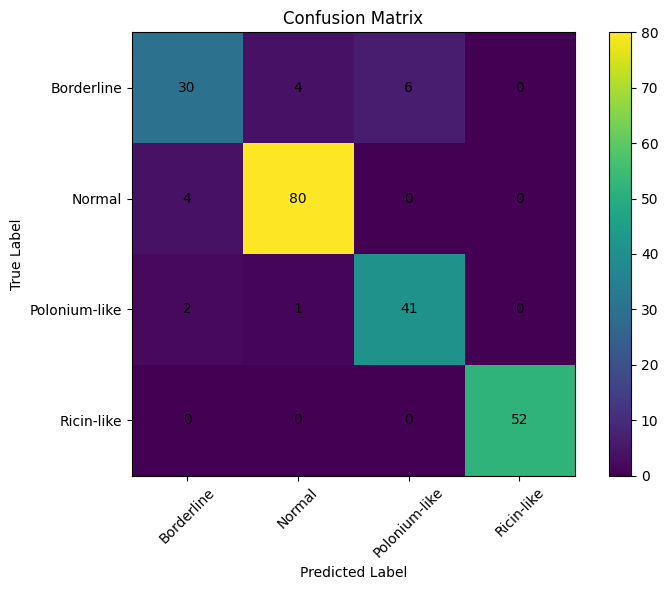

In [19]:
plt.figure(figsize=(8, 6))
plt.imshow(cm_df, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(cm_df.columns)), cm_df.columns, rotation=45)
plt.yticks(range(len(cm_df.index)), cm_df.index)

for i in range(len(cm_df.index)):
    for j in range(len(cm_df.columns)):
        plt.text(j, i, cm_df.iloc[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [20]:
feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": best_rf.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
17,time_to_onset_hours,0.310035
14,marrow_suppression,0.106299
15,renal_injury_score,0.089743
13,multi_organ_damage,0.062476
16,hepatic_injury_score,0.058640
8,radiation_pattern,0.057385
11,cell_damage_score,0.054208
12,gi_damage_score,0.043565
10,weakness_score,0.042157
7,feed_exposure,0.036909


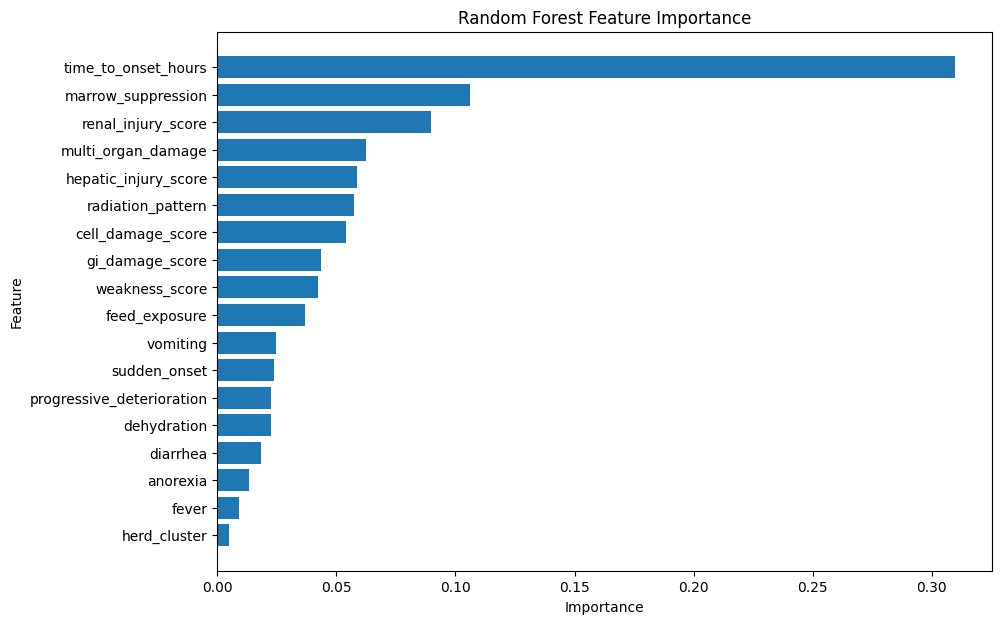

In [21]:
top_features = feature_importance.sort_values(by="importance", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.show()

In [22]:
calibrated_model = CalibratedClassifierCV(
    estimator=best_rf,
    method="sigmoid",
    cv=3
)

In [23]:
calibrated_model.fit(X_train, y_train)

CalibratedClassifierCV(cv=3,
                       estimator=RandomForestClassifier(class_weight='balanced',
                                                        min_samples_split=5,
                                                        n_estimators=300,
                                                        random_state=42))

In [24]:
calibrated_test_pred = calibrated_model.predict(X_test)
calibrated_test_accuracy = accuracy_score(y_test, calibrated_test_pred)

print("=== After Calibration ===")
print("Calibrated Test Accuracy:", round(calibrated_test_accuracy, 4))

=== After Calibration ===
Calibrated Test Accuracy: 0.9182


In [25]:
print(classification_report(y_test, calibrated_test_pred))

               precision    recall  f1-score   support

   Borderline       0.79      0.78      0.78        40
       Normal       0.94      0.94      0.94        84
Polonium-like       0.91      0.91      0.91        44
   Ricin-like       0.98      1.00      0.99        52

     accuracy                           0.92       220
    macro avg       0.91      0.91      0.91       220
 weighted avg       0.92      0.92      0.92       220



In [26]:
cv_scores = cross_val_score(best_rf, X, y, cv=cv, scoring="accuracy")

print("Cross Validation Scores:", cv_scores)
print("Cross Validation Mean:", round(cv_scores.mean(), 4))

Cross Validation Scores: [0.91363636 0.94545455 0.95       0.93181818 0.94090909]
Cross Validation Mean: 0.9364


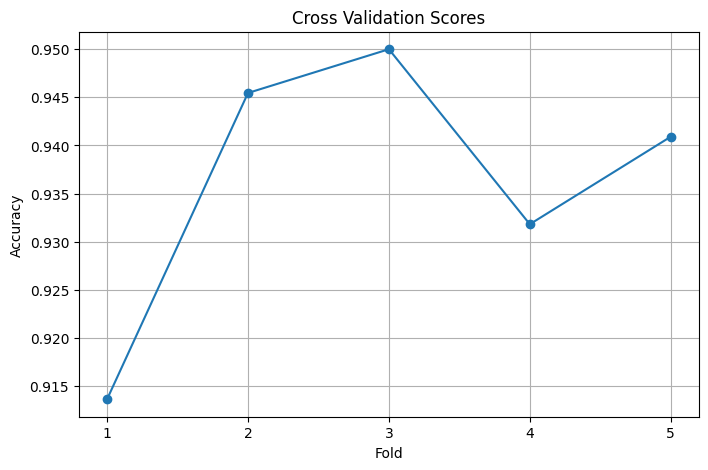

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), cv_scores, marker="o")
plt.xticks(range(1, 6))
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Cross Validation Scores")
plt.grid(True)
plt.show()

In [28]:
def predict_case(case_features,
                 high_threshold=0.85,
                 moderate_threshold=0.70,
                 margin_threshold=0.10):

    probabilities = calibrated_model.predict_proba(case_features)[0]
    classes = calibrated_model.classes_

    sorted_indices = np.argsort(probabilities)[::-1]
    top1_idx = sorted_indices[0]
    top2_idx = sorted_indices[1]

    top1_prob = probabilities[top1_idx]
    top2_prob = probabilities[top2_idx]

    prediction = classes[top1_idx]
    second_class = classes[top2_idx]

    margin = top1_prob - top2_prob

    is_borderline_like = (
        (top1_prob < 0.65) or
        (margin < 0.25)
    )

    if "Borderline" in [prediction, second_class] and margin < 0.30:
        confidence_level = "⚠️ Borderline likely"
    elif is_borderline_like:
        confidence_level = "⚠️ Borderline / Uncertain case"
    elif top1_prob >= high_threshold and margin >= margin_threshold:
        confidence_level = "High confidence prediction"
    elif top1_prob >= moderate_threshold:
        confidence_level = "Moderate confidence prediction"
    else:
        confidence_level = "Low confidence prediction"

    return {
        "prediction": prediction,
        "second_possible": second_class,
        "confidence": float(round(top1_prob * 100, 2)),
        "margin_top1_top2": float(round(margin * 100, 2)),
        "probabilities": probabilities.tolist(),
        "confidence_level": confidence_level
    }

In [29]:
sample = X_test.iloc[[0]]
result = predict_case(sample)
result

{'prediction': 'Normal',
 'second_possible': 'Borderline',
 'confidence': 87.91,
 'margin_top1_top2': 76.85,
 'probabilities': [0.11057038883767618,
  0.8790596590795463,
  0.004429691486728901,
  0.005940260596048408],
 'confidence_level': 'High confidence prediction'}

In [30]:
uncertain_cases = []

for i in range(len(X_test)):
    sample = X_test.iloc[[i]]
    result = predict_case(sample)

    if (
        result["prediction"] == "Borderline"
        or (
            result["second_possible"] == "Borderline"
            and result["margin_top1_top2"] < 20
        )
        or (
            result["confidence"] < 70
            and result["margin_top1_top2"] < 10
        )
    ):
        uncertain_cases.append((i, result))

len(uncertain_cases)

44

In [31]:
borderline_indices = y_test[y_test == "Borderline"].index

In [32]:
analysis = []

for idx in borderline_indices:
    sample = X_test.loc[[idx]]
    result = predict_case(sample)

    analysis.append({
        "true_label": "Borderline",
        "predicted": result["prediction"],
        "confidence": result["confidence"],
        "margin": result["margin_top1_top2"],
        "confidence_level": result["confidence_level"]
    })

analysis_df = pd.DataFrame(analysis)
analysis_df

,true_label,predicted,confidence,margin,confidence_level
0,Borderline,Borderline,95.33,92.75,High confidence prediction
1,Borderline,Borderline,71.65,44.16,Moderate confidence prediction
2,Borderline,Borderline,88.52,78.14,High confidence prediction
3,Borderline,Borderline,93.55,88.73,High confidence prediction
4,Borderline,Borderline,93.47,88.06,High confidence prediction
5,Borderline,Normal,52.99,6.72,⚠️ Borderline likely
6,Borderline,Polonium-like,86.49,74.58,High confidence prediction
7,Borderline,Ricin-like,57.28,16.35,⚠️ Borderline likely
8,Borderline,Borderline,58.37,17.68,⚠️ Borderline likely
9,Borderline,Borderline,95.35,93.45,High confidence prediction


In [33]:
analysis_df["predicted"].value_counts()

predicted
Borderline       31
Normal            4
Polonium-like     4
Ricin-like        1
Name: count, dtype: int64

In [34]:
analysis_df.sort_values(by="confidence", ascending=False)

,true_label,predicted,confidence,margin,confidence_level
28,Borderline,Borderline,96.95,95.44,High confidence prediction
33,Borderline,Borderline,95.45,93.26,High confidence prediction
9,Borderline,Borderline,95.35,93.45,High confidence prediction
0,Borderline,Borderline,95.33,92.75,High confidence prediction
18,Borderline,Borderline,95.22,92.01,High confidence prediction
15,Borderline,Borderline,93.69,91.42,High confidence prediction
3,Borderline,Borderline,93.55,88.73,High confidence prediction
4,Borderline,Borderline,93.47,88.06,High confidence prediction
21,Borderline,Normal,92.99,87.09,High confidence prediction
23,Borderline,Borderline,90.77,86.38,High confidence prediction


In [35]:
missed_borderline_cases = analysis_df[
    ~analysis_df["confidence_level"].str.contains("Borderline")
]

missed_borderline_cases

,true_label,predicted,confidence,margin,confidence_level
0,Borderline,Borderline,95.33,92.75,High confidence prediction
1,Borderline,Borderline,71.65,44.16,Moderate confidence prediction
2,Borderline,Borderline,88.52,78.14,High confidence prediction
3,Borderline,Borderline,93.55,88.73,High confidence prediction
4,Borderline,Borderline,93.47,88.06,High confidence prediction
6,Borderline,Polonium-like,86.49,74.58,High confidence prediction
9,Borderline,Borderline,95.35,93.45,High confidence prediction
10,Borderline,Borderline,83.53,69.13,Moderate confidence prediction
12,Borderline,Borderline,88.22,77.52,High confidence prediction
13,Borderline,Borderline,90.45,83.89,High confidence prediction


In [36]:
len(missed_borderline_cases)

32

In [37]:
missed_borderline_cases.sort_values(by="confidence", ascending=False)

,true_label,predicted,confidence,margin,confidence_level
28,Borderline,Borderline,96.95,95.44,High confidence prediction
33,Borderline,Borderline,95.45,93.26,High confidence prediction
9,Borderline,Borderline,95.35,93.45,High confidence prediction
0,Borderline,Borderline,95.33,92.75,High confidence prediction
18,Borderline,Borderline,95.22,92.01,High confidence prediction
15,Borderline,Borderline,93.69,91.42,High confidence prediction
3,Borderline,Borderline,93.55,88.73,High confidence prediction
4,Borderline,Borderline,93.47,88.06,High confidence prediction
21,Borderline,Normal,92.99,87.09,High confidence prediction
23,Borderline,Borderline,90.77,86.38,High confidence prediction


In [38]:
missed_wrong_borderline = analysis_df[
    (analysis_df["true_label"] == "Borderline") &
    (analysis_df["predicted"] != "Borderline")
]

missed_wrong_borderline

,true_label,predicted,confidence,margin,confidence_level
5,Borderline,Normal,52.99,6.72,⚠️ Borderline likely
6,Borderline,Polonium-like,86.49,74.58,High confidence prediction
7,Borderline,Ricin-like,57.28,16.35,⚠️ Borderline likely
11,Borderline,Polonium-like,51.80,5.22,⚠️ Borderline likely
17,Borderline,Normal,76.00,52.79,Moderate confidence prediction
21,Borderline,Normal,92.99,87.09,High confidence prediction
24,Borderline,Normal,82.32,65.49,Moderate confidence prediction
25,Borderline,Polonium-like,60.67,22.66,⚠️ Borderline likely
27,Borderline,Polonium-like,87.46,77.02,High confidence prediction


In [39]:
missed_wrong_borderline["predicted"].value_counts()

predicted
Normal           4
Polonium-like    4
Ricin-like       1
Name: count, dtype: int64

In [40]:
correct_indices = []

for idx in borderline_indices:
    sample = X_test.loc[[idx]]
    result = predict_case(sample)
    if result["prediction"] == "Borderline":
        correct_indices.append(idx)

X_test.loc[correct_indices].mean().round(2)

fever                         0.42
vomiting                      0.42
diarrhea                      0.48
anorexia                      0.61
dehydration                   0.42
sudden_onset                  0.45
progressive_deterioration     0.45
feed_exposure                 0.29
radiation_pattern             0.32
herd_cluster                  0.32
weakness_score                1.77
cell_damage_score             1.74
gi_damage_score               2.00
multi_organ_damage            1.74
marrow_suppression            1.74
renal_injury_score            1.39
hepatic_injury_score          1.65
time_to_onset_hours          42.58
dtype: float64

In [41]:
missed_indices = []

for idx in borderline_indices:
    sample = X_test.loc[[idx]]
    result = predict_case(sample)
    if result["prediction"] != "Borderline":
        missed_indices.append(idx)

X_test.loc[missed_indices].mean().round(2)

fever                         0.56
vomiting                      0.22
diarrhea                      0.33
anorexia                      0.78
dehydration                   0.33
sudden_onset                  0.22
progressive_deterioration     0.56
feed_exposure                 0.33
radiation_pattern             0.33
herd_cluster                  0.11
weakness_score                2.44
cell_damage_score             1.89
gi_damage_score               1.56
multi_organ_damage            1.89
marrow_suppression            1.56
renal_injury_score            1.67
hepatic_injury_score          1.78
time_to_onset_hours          48.33
dtype: float64

In [43]:
joblib.dump(calibrated_model, "calibrated_random_forest_model.pkl")
joblib.dump(feature_columns, "feature_columns.pkl")

print("Model and feature columns saved successfully.")

Model and feature columns saved successfully.
